In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

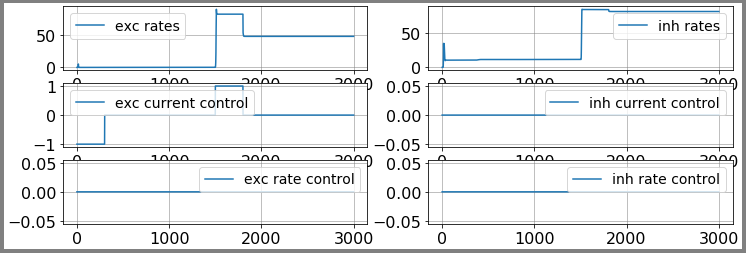

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

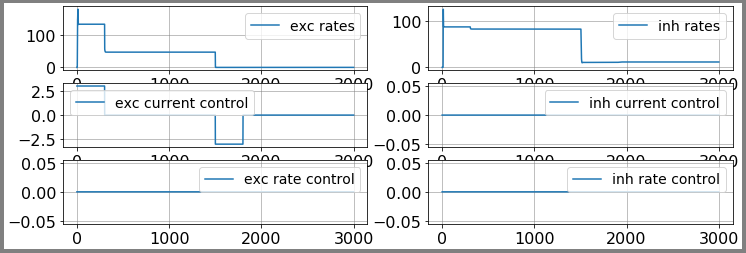

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000

initVars = low_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "A"

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])

In [6]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

## 14

set cost params
control input:  [0] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  1045.439946239643
RUN  2 , total integrated cost =  86.55806175419859
RUN  3 , total integrated cost =  20.99085769377863
RUN  4 , total integrated cost =  11.415316117122773
RUN  5 , total integrated cost =  8.841145629144
RUN  6 , total integrated cost =  7.735286070767241
RUN  7 , total integrated cost =  7.1271546943338056
RUN  8 , total integrated cost =  6.730222675410853
RUN  9 , total integrated cost =  6.45635201728128
RUN  10 , total integrated cost =  6.235204681211816
RUN  11 , total integrated cost =  6.054076613224214
RUN  12 , total integrated cost =  5.893840157134448
RUN  13 , total integrated cost =  5.750102949415783
RUN  14 , total integrated cost =  5.6205017392912735
RUN  15 , total integrated cost =  5.496821513640515
RUN  16 , total integrated cost =  5.382170184534994
RUN  17

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.0013283836490846652
RUN  5000 , total integrated cost =  0.0013283836490846652
Improved over  5000  iterations by  99.99999816980883  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459095789589 -56.17459097802795


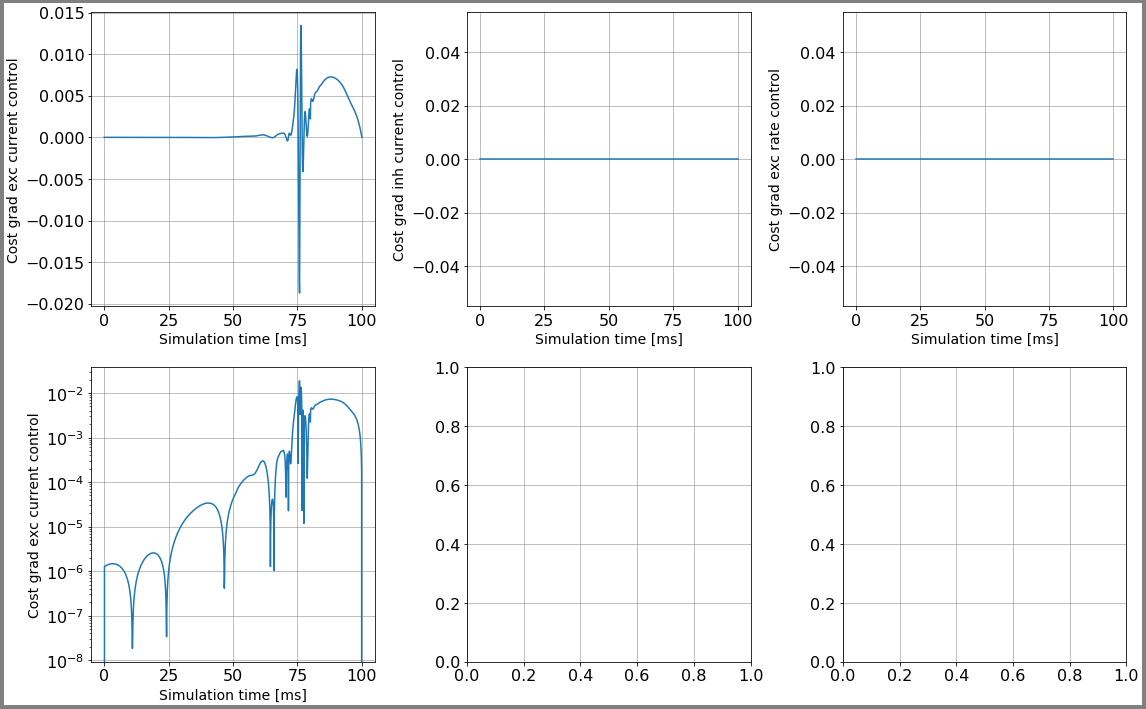

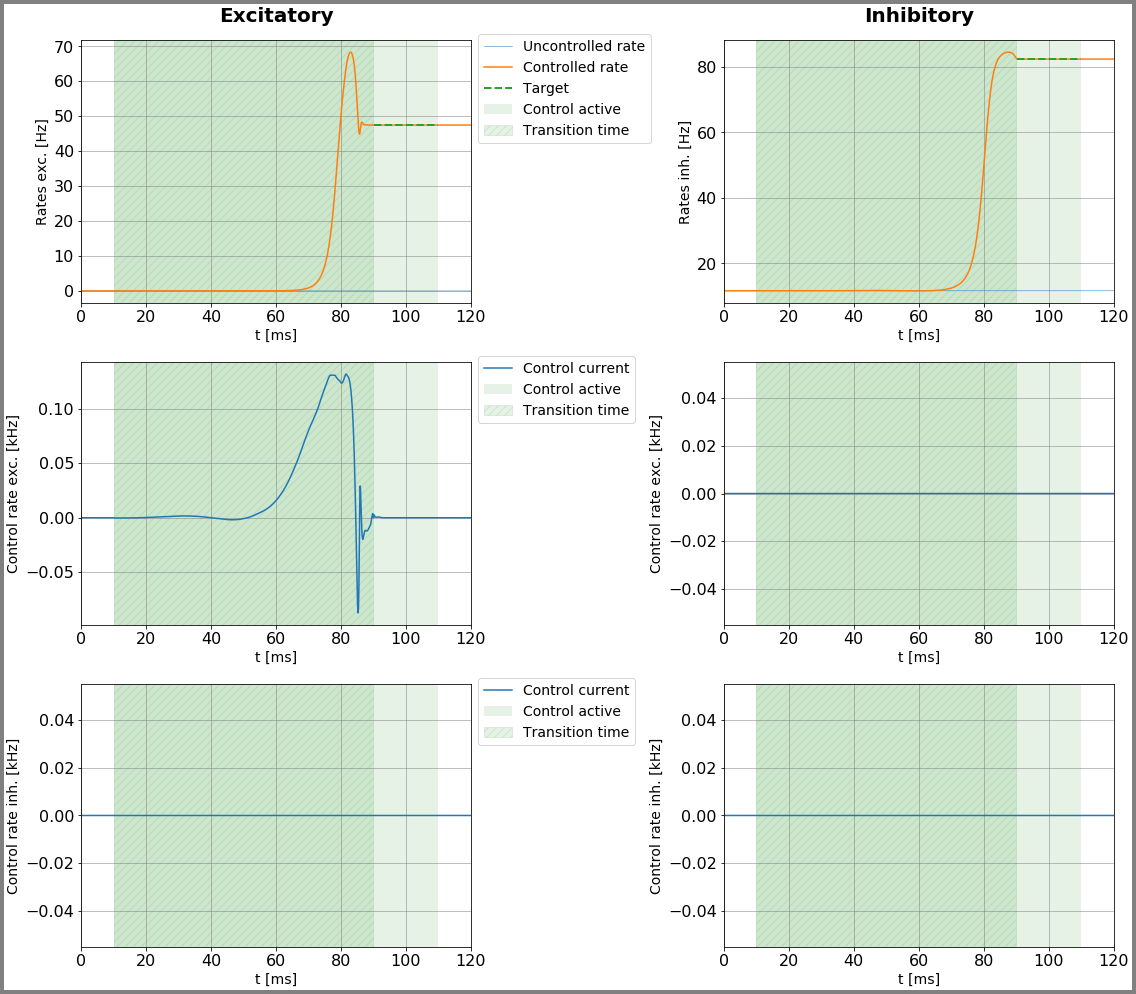

In [7]:
# B.0.a)

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 14
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  1187.387571665953
RUN  2 , total integrated cost =  250.61101033678102
RUN  3 , total integrated cost =  168.55234954915778
RUN  4 , total integrated cost =  146.48457747635015
RUN  5 , total integrated cost =  130.75616240563036
RUN  6 , total integrated cost =  117.014709004102
RUN  7 , total integrated cost =  104.21162322248946
RUN  8 , total integrated cost =  93.73090378476127
RUN  9 , total integrated cost =  86.28731564124868
RUN  10 , total integrated cost =  82.65823217869703
RUN  11 , total integrated cost =  80.35248329002053
RUN  12 , total integrated cost =  78.34614600265655
RUN  13 , total integrated cost =  76.82588977849454
RUN  14 , total integrated cost =  75.24426923305755
RUN  15 , total integrated cost =  73.97632680214467
RUN  16 , total integrated cost =  72.59185027554454
RUN  17 , total integrated cost =  71.4702709981974

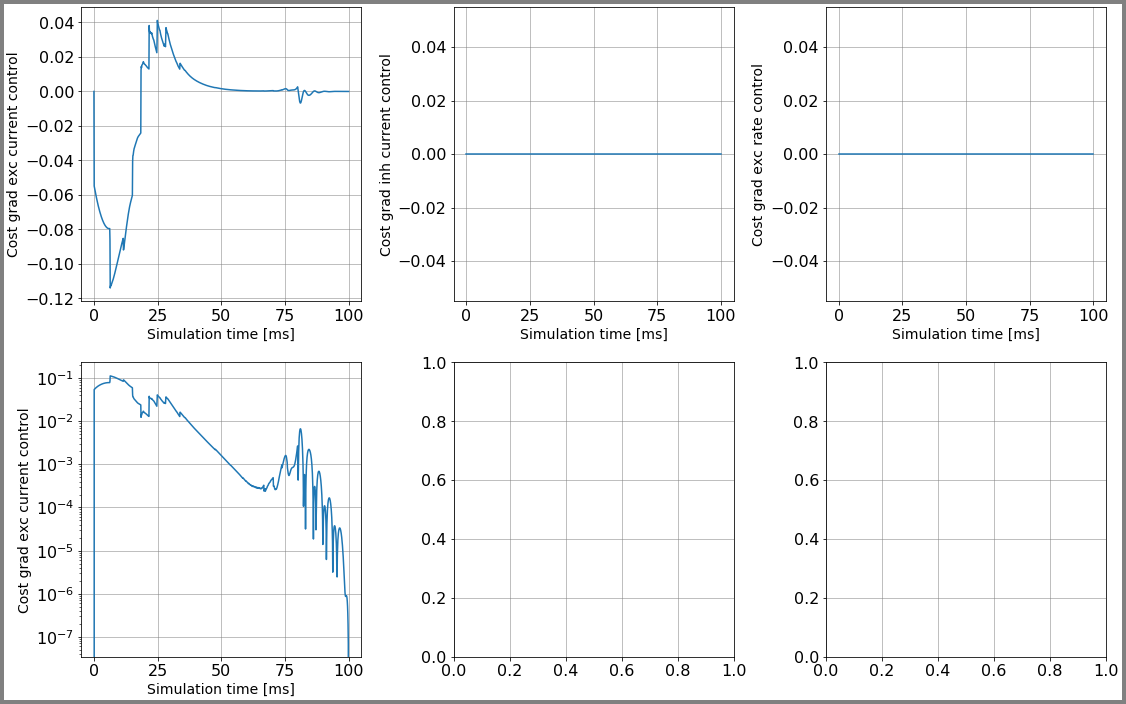

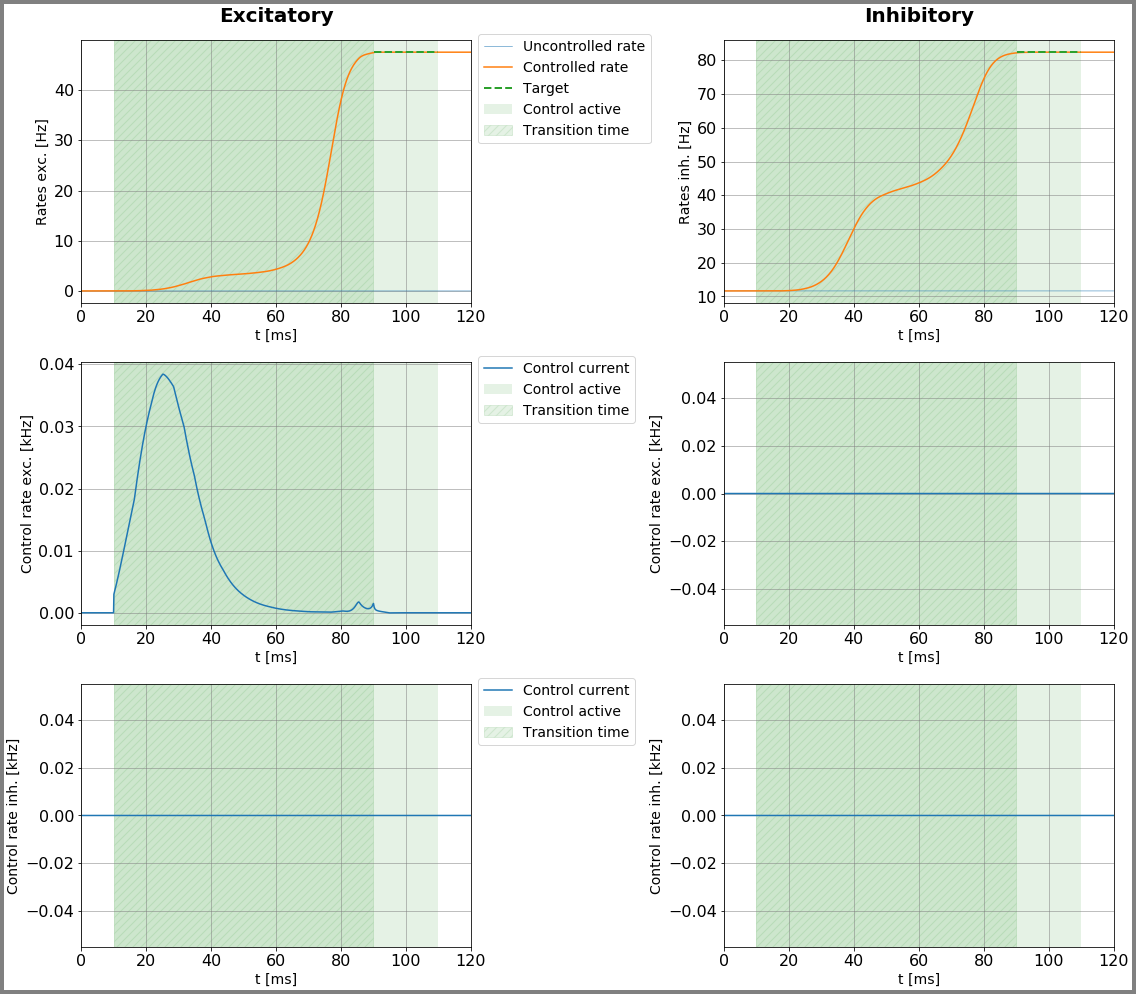

In [8]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 14
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 15

set cost params
control input:  [1] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  2077.7308408855724
RUN  2 , total integrated cost =  250.76732309652937
RUN  3 , total integrated cost =  6.206945394507586
RUN  4 , total integrated cost =  1.0989427399790646
RUN  5 , total integrated cost =  0.517816200803236
RUN  6 , total integrated cost =  0.3592583048161434
RUN  7 , total integrated cost =  0.28668285964686785
RUN  8 , total integrated cost =  0.24569119015939636
RUN  9 , total integrated cost =  0.22037931812839062
RUN  10 , total integrated cost =  0.20341394033778185
RUN  11 , total integrated cost =  0.19083992843971945
RUN  12 , total integrated cost =  0.1816958979228251
RUN  13 , total integrated cost =  0.1745224753295525
RUN  14 , total integrated cost =  0.16889298756447502
RUN  15 , total integrated cost =  0.16364184713144087
RUN  16 , total integrated cost =  0.15

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.0019958261105268126
RUN  5000 , total integrated cost =  0.0019958261105268126
Improved over  5000  iterations by  99.99999725023467  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459219840829 -56.17459217263585


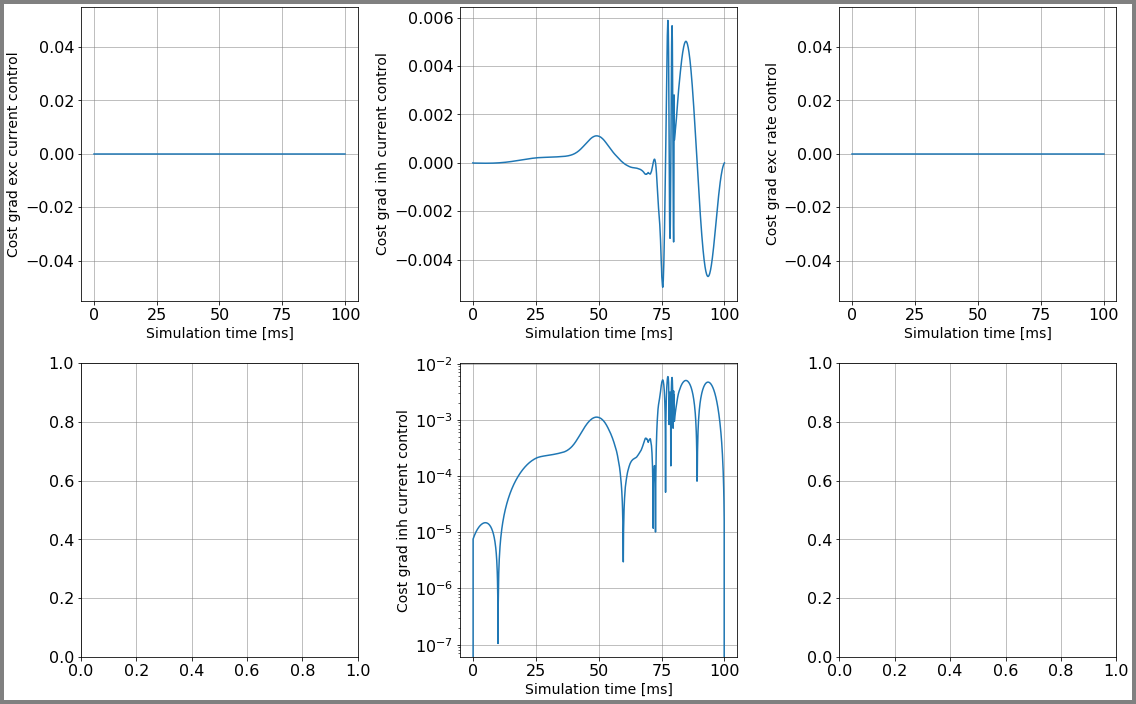

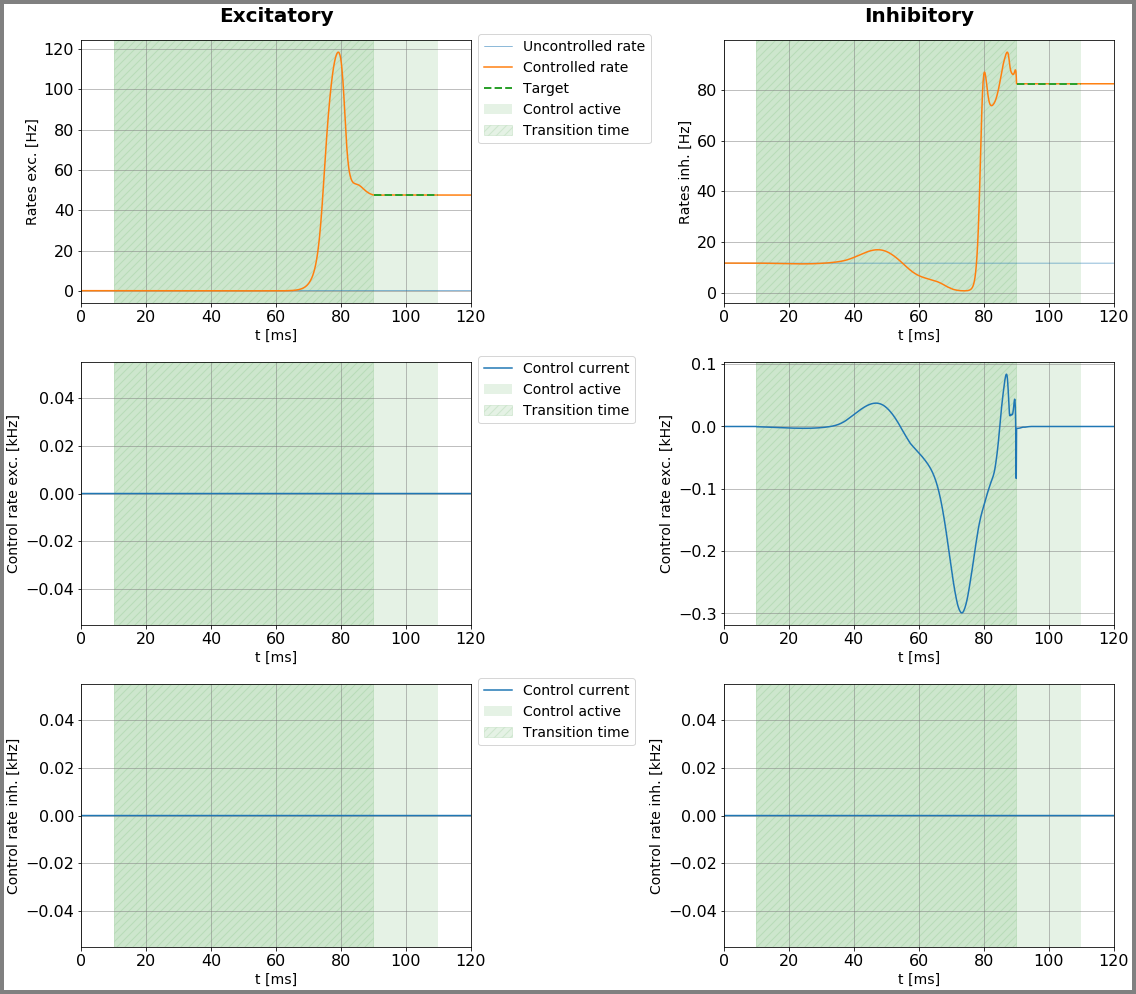

In [9]:
case_ind = 15
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  2190.816067323479
RUN  2 , total integrated cost =  487.0084707494409
RUN  3 , total integrated cost =  156.7749590427287
RUN  4 , total integrated cost =  89.85145758999704
RUN  5 , total integrated cost =  58.62677017057074
RUN  6 , total integrated cost =  47.86608631117923
RUN  7 , total integrated cost =  41.915760252611456
RUN  8 , total integrated cost =  40.39059802071998
RUN  9 , total integrated cost =  39.78550423143808
RUN  10 , total integrated cost =  39.18416449326605
RUN  11 , total integrated cost =  38.737165139123476
RUN  12 , total integrated cost =  38.27259597955431
RUN  13 , total integrated cost =  37.8956515039223
RUN  14 , total integrated cost =  37.48860763001463
RUN  15 , total integrated cost =  37.145408642635616
RUN  16 , total integrated cost =  36.77752823486188
RUN  17 , total integrated cost =  36.45924122416436


ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  14.832673552423204
RUN  5000 , total integrated cost =  14.832673552423204
Improved over  5000  iterations by  99.97956416577087  percent.
Problem in initial value trasfer:  Vmean_exc -56.17458882359441 -56.174588905377774


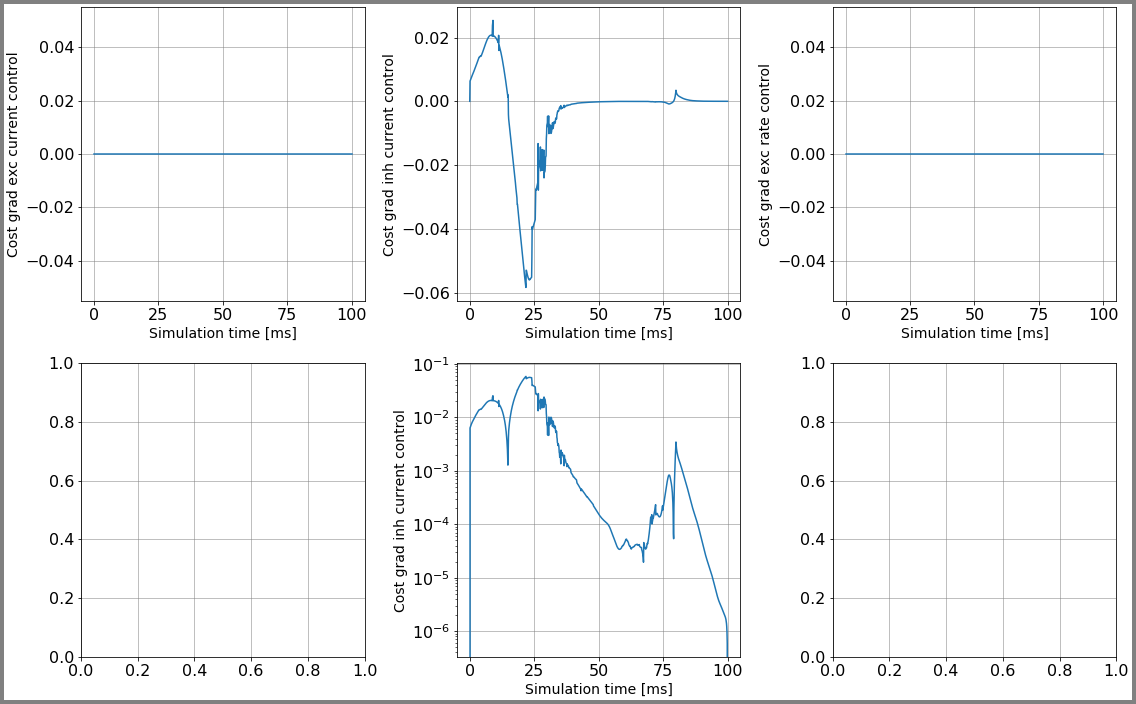

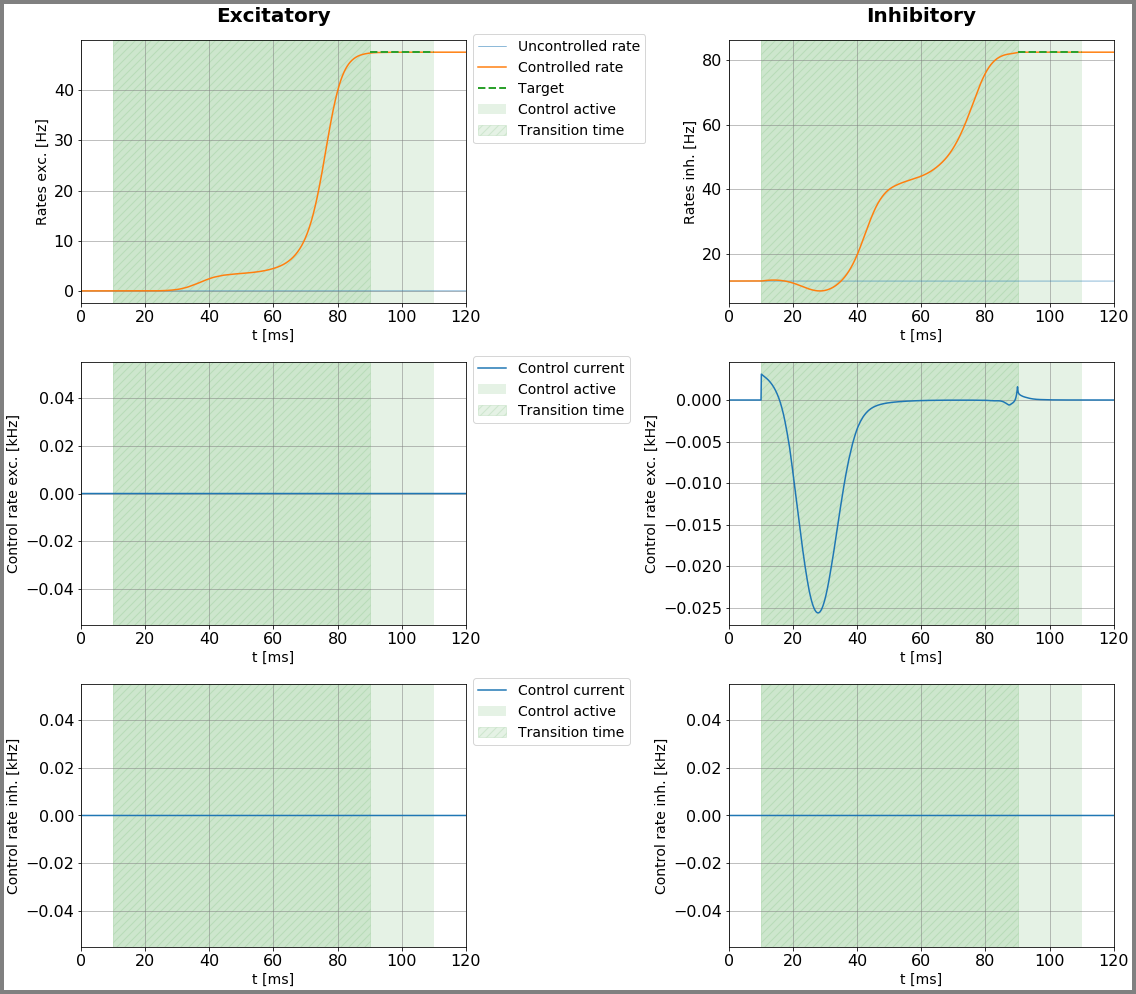

In [10]:
case_ind = 15
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 16

set cost params
control input:  [2] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  15.61677338951691
RUN  2 , total integrated cost =  0.0003767804495250874
RUN  3 , total integrated cost =  3.849006968745646e-07
RUN  4 , total integrated cost =  1.6522046718200286e-10
RUN  5 , total integrated cost =  3.8549897146995815e-13
RUN  6 , total integrated cost =  2.5082491277829337e-16
RUN  7 , total integrated cost =  8.855875672689952e-19
RUN  8 , total integrated cost =  6.496914299979199e-22
RUN  9 , total integrated cost =  2.203233855998771e-22
RUN  10 , total integrated cost =  1.574873277889479e-22
RUN  11 , total integrated cost =  1.2188837016460343e-22
RUN  12 , total integrated cost =  5.874489388999831e-23
RUN  13 , total integrated cost =  2.2118397604948776e-25
RUN  14 , total integrated cost =  1.2762633486772306e-25
RUN  15 , total integrated cost =  1.1398472100591727e

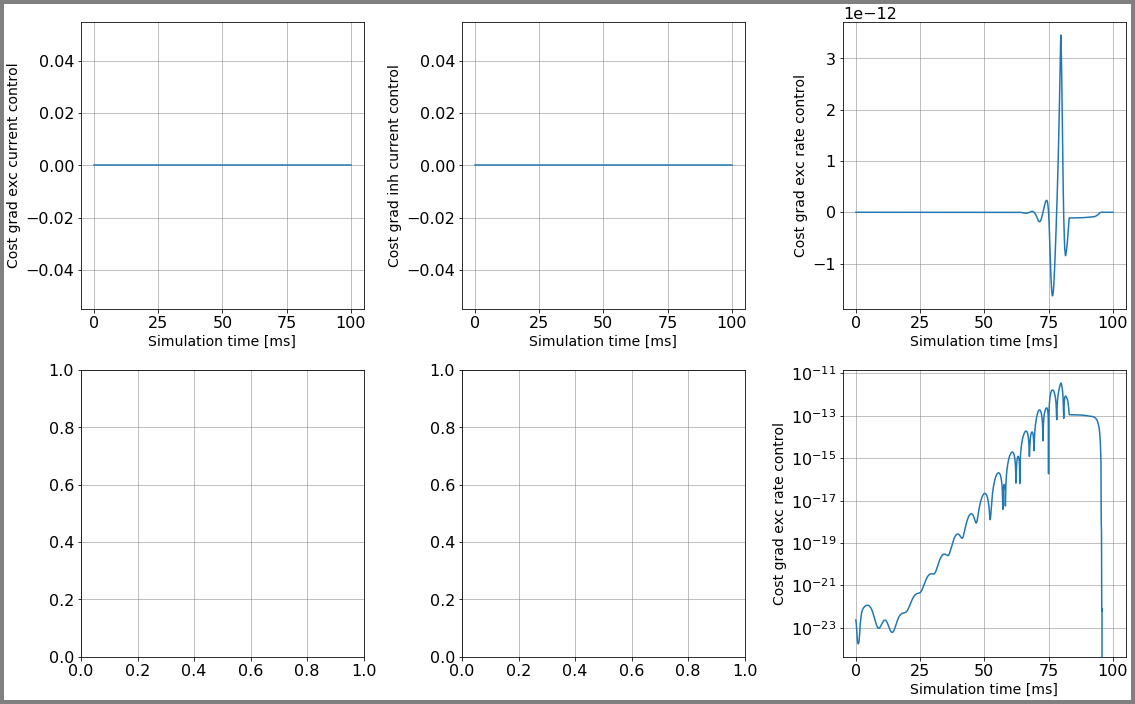

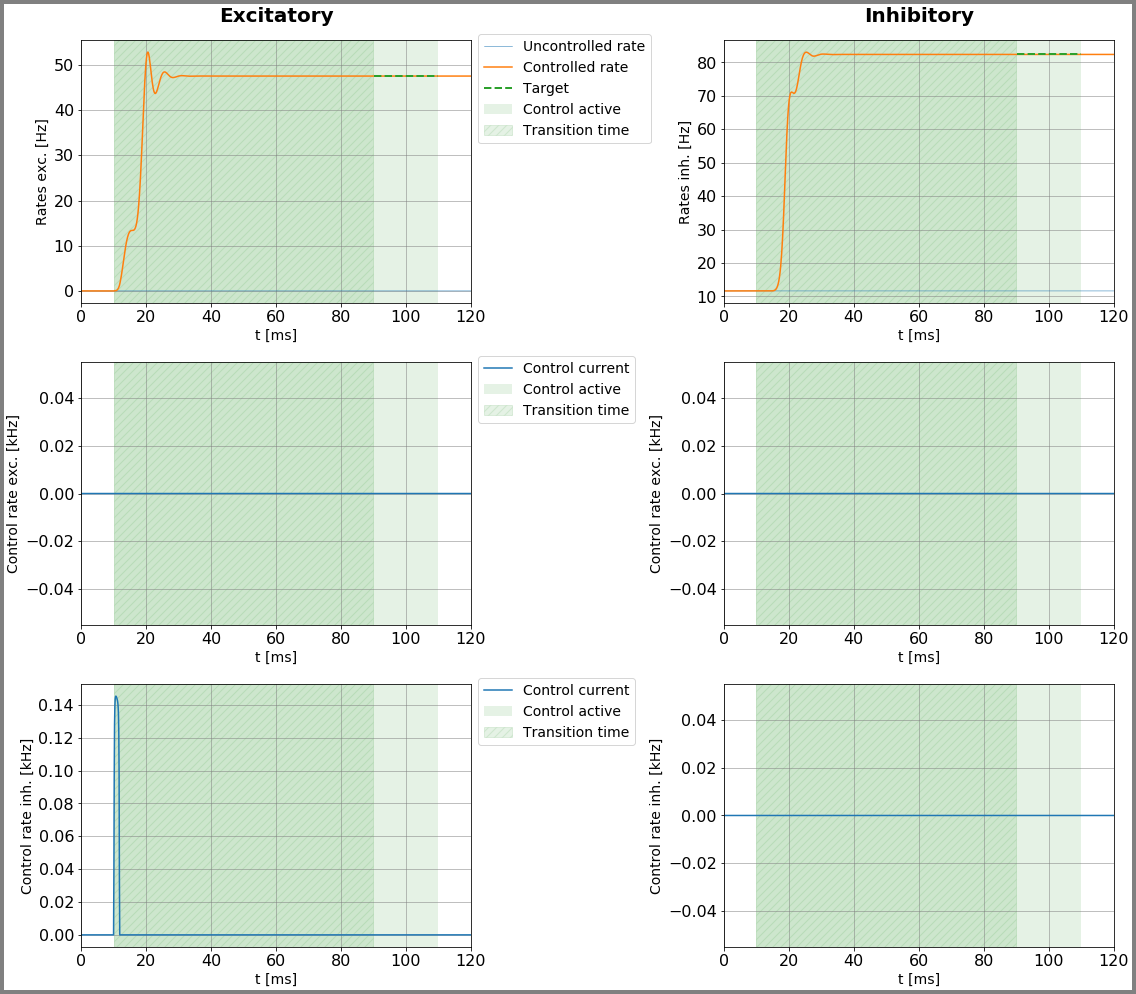

In [11]:
# A.4.a)

case_ind = 16
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  21.406126419675783
RUN  2 , total integrated cost =  19.99674085082043
RUN  3 , total integrated cost =  0.818166775706769
RUN  4 , total integrated cost =  0.21305648888998518
RUN  5 , total integrated cost =  0.21273371008281036
RUN  6 , total integrated cost =  0.21256863595911596
RUN  7 , total integrated cost =  0.21239465872836363
RUN  8 , total integrated cost =  0.21225190937508157
RUN  9 , total integrated cost =  0.21210140877270736
RUN  10 , total integrated cost =  0.2119467075472127
RUN  11 , total integrated cost =  0.21176902252458016
RUN  12 , total integrated cost =  0.21151641739515614
RUN  13 , total integrated cost =  0.21126296617505996
RUN  14 , total integrated cost =  0.2109722505801051
RUN  15 , total integrated cost =  0.21064864241772224
RUN  16 , total integrated cost =  0.21046886979182278
RUN  17 , total integrated cos

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.18328551041613464
RUN  5000 , total integrated cost =  0.18328551041613464
Improved over  5000  iterations by  99.99974747692691  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7145072726007248
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.104443533096923


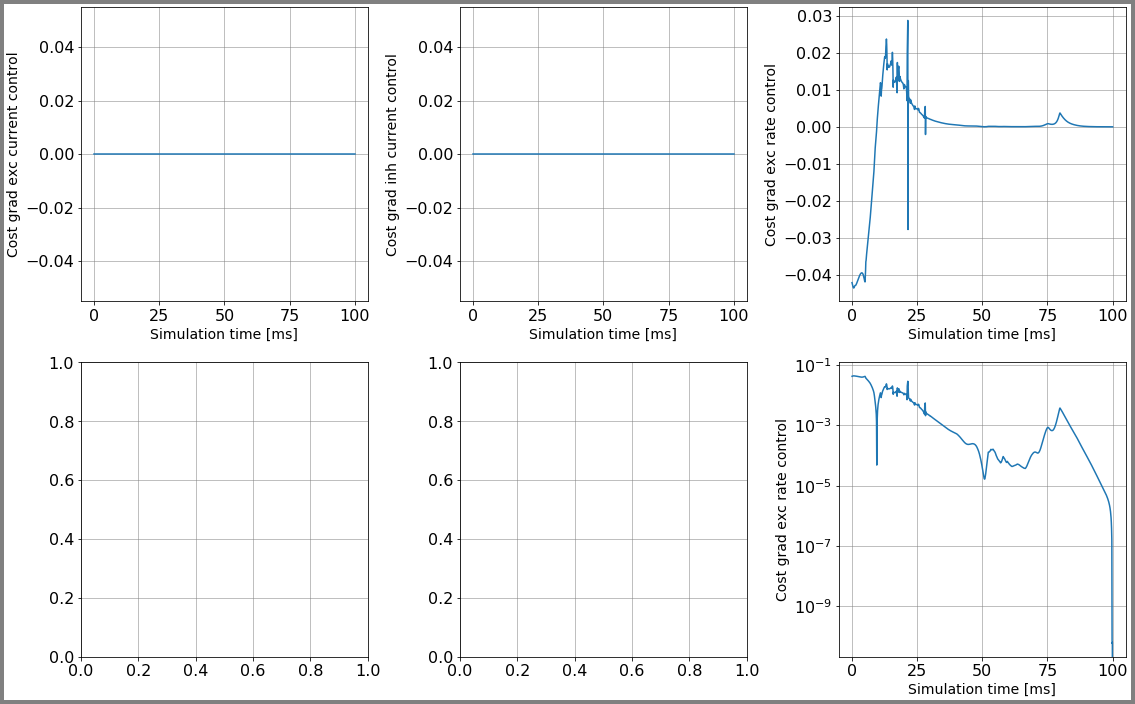

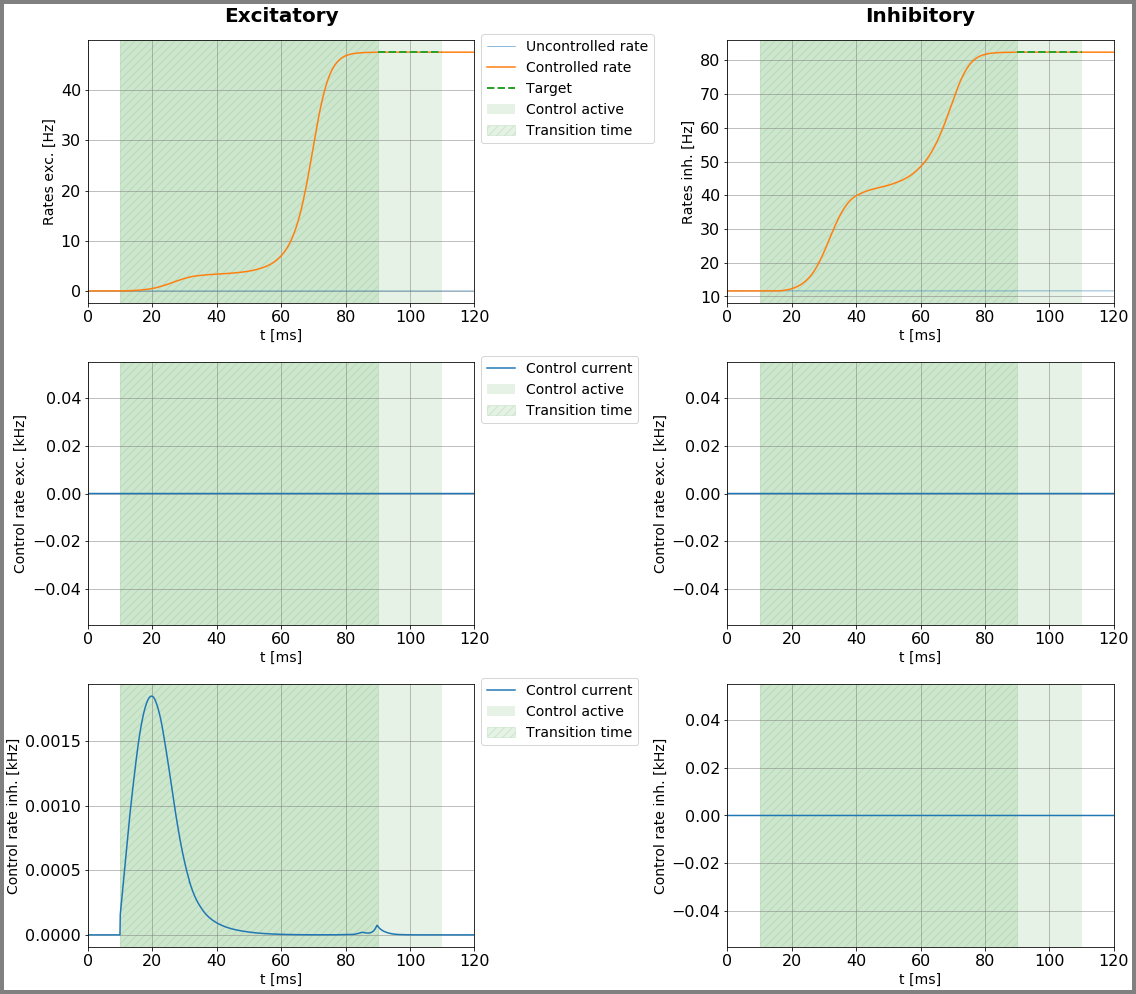

In [12]:
case_ind = 16
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 17

set cost params
control input:  [0, 1] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  1045.439946239643
RUN  2 , total integrated cost =  86.55806175419859
RUN  3 , total integrated cost =  15.00185423566835
RUN  4 , total integrated cost =  5.069256966382067
RUN  5 , total integrated cost =  2.5607661948237452
RUN  6 , total integrated cost =  1.550704513162249
RUN  7 , total integrated cost =  1.0366138442841373
RUN  8 , total integrated cost =  0.746001891381434
RUN  9 , total integrated cost =  0.5689711576423302
RUN  10 , total integrated cost =  0.4472959706906452
RUN  11 , total integrated cost =  0.3629426444224272
RUN  12 , total integrated cost =  0.30189689529154395
RUN  13 , total integrated cost =  0.2542958582584232
RUN  14 , total integrated cost =  0.2179994674084352
RUN  15 , total integrated cost =  0.1892113067647779
RUN  16 , total integrated cost =  0.165589241

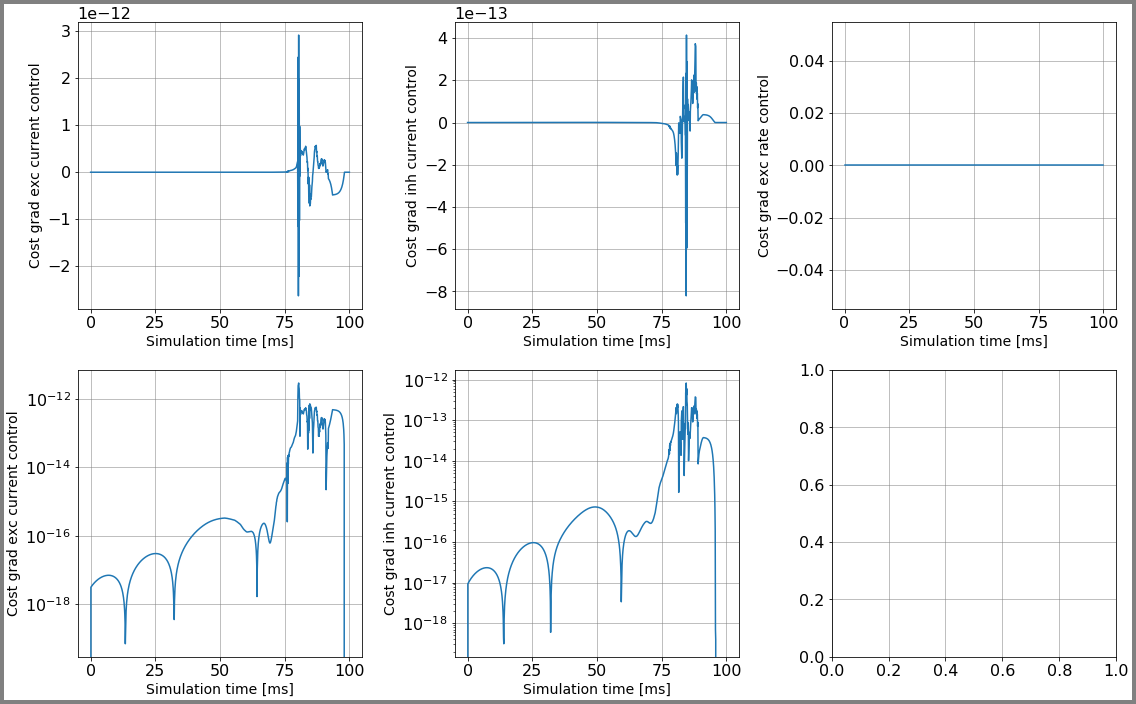

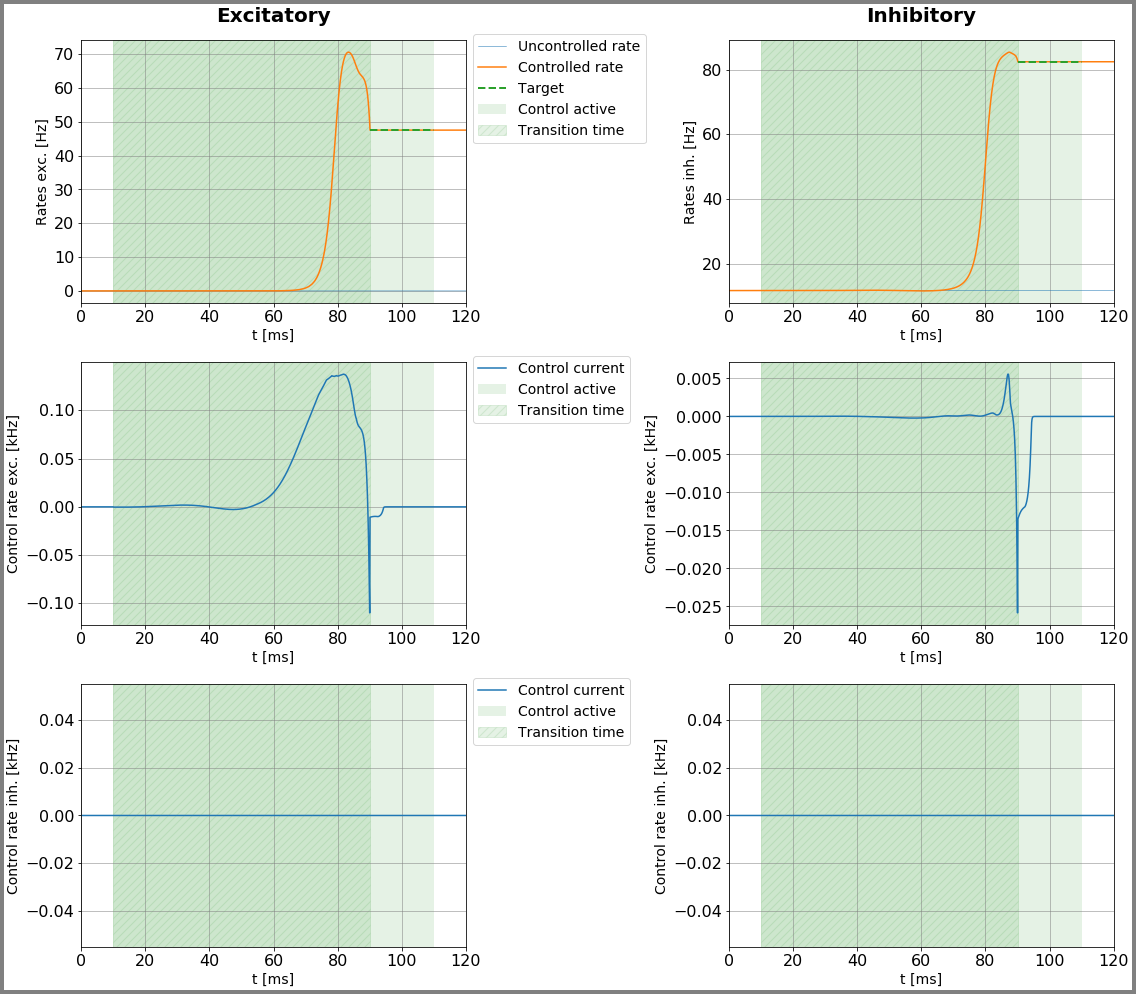

In [13]:
# A.6.a)
case_ind = 17
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  1187.387571665953
RUN  2 , total integrated cost =  250.61101033678102
RUN  3 , total integrated cost =  167.45024730904137
RUN  4 , total integrated cost =  146.99457283390626
RUN  5 , total integrated cost =  132.75804599256645
RUN  6 , total integrated cost =  119.888357505307
RUN  7 , total integrated cost =  108.30935035640641
RUN  8 , total integrated cost =  97.72114707982155
RUN  9 , total integrated cost =  89.51597121204357
RUN  10 , total integrated cost =  84.24829133179882
RUN  11 , total integrated cost =  80.74599961660834
RUN  12 , total integrated cost =  77.49787924101605
RUN  13 , total integrated cost =  75.35675911077949
RUN  14 , total integrated cost =  72.8295238508495
RUN  15 , total integrated cost =  71.16976715998399
RUN  16 , total integrated cost =  67.71516325377748
RUN  17 , total integrated cost =  66.17353394270367

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3569 , total integrated cost =  14.831177556003404
Improved over  3569  iterations by  99.97956622689186  percent.
Problem in initial value trasfer:  Vmean_exc -56.17458885286644 -56.174588933672894


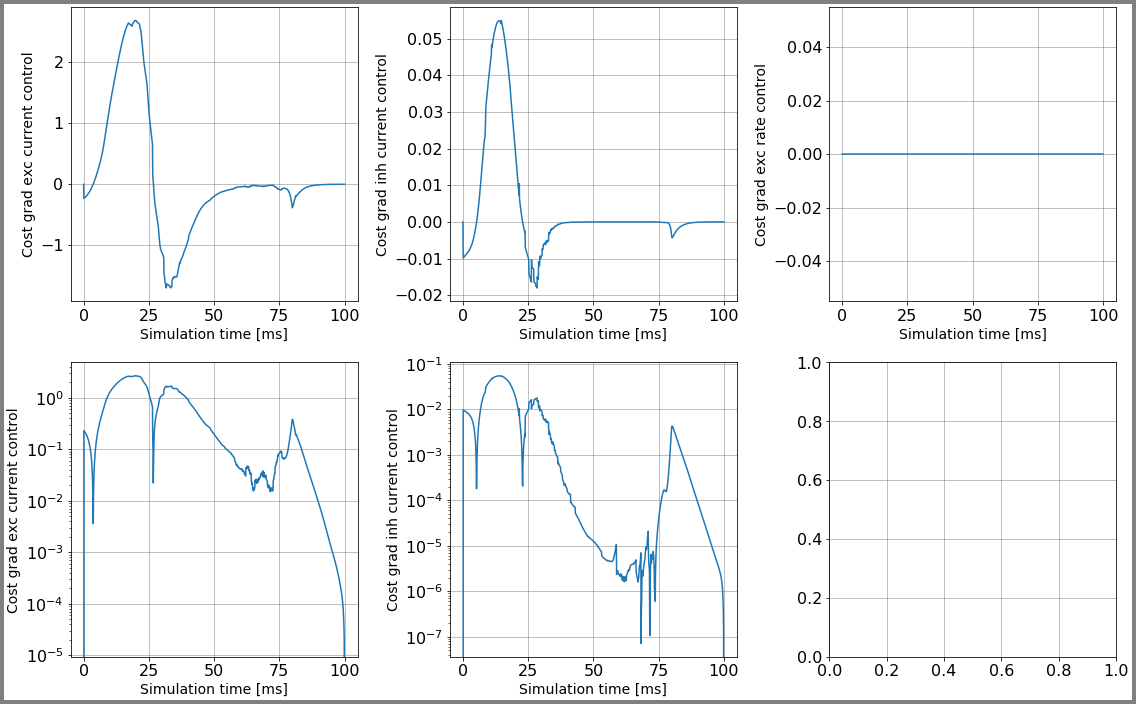

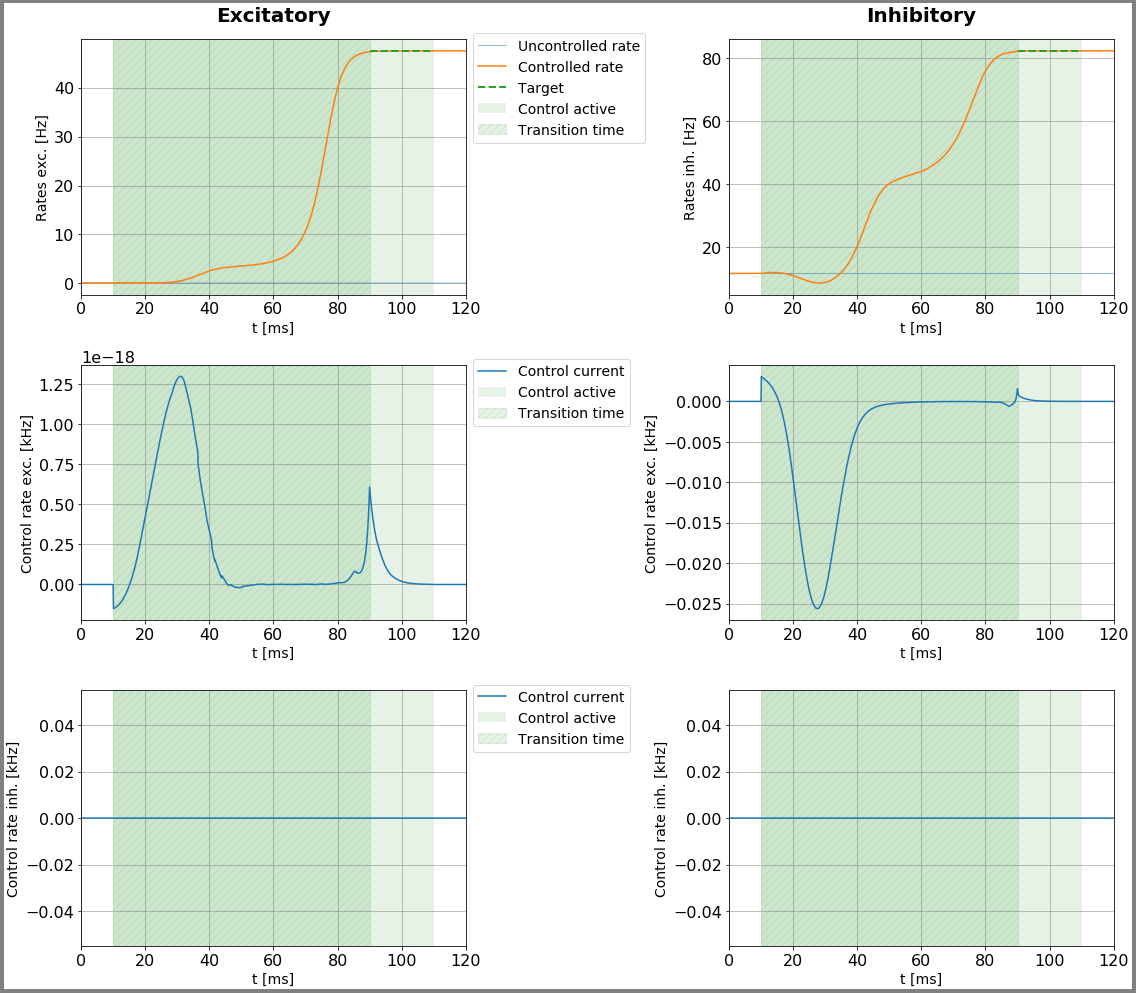

In [14]:
case_ind = 17
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 18

set cost params
control input:  [0, 2] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  15.61677338951691
RUN  2 , total integrated cost =  0.0003767804495250874
RUN  3 , total integrated cost =  3.849006968745646e-07
RUN  4 , total integrated cost =  1.6522046718200286e-10
RUN  5 , total integrated cost =  3.8549897146995815e-13
RUN  6 , total integrated cost =  2.5082491277829337e-16
RUN  7 , total integrated cost =  8.855875672689952e-19
RUN  8 , total integrated cost =  6.496914299979199e-22
RUN  9 , total integrated cost =  2.203233855998771e-22
RUN  10 , total integrated cost =  1.0541780264683371e-22
RUN  11 , total integrated cost =  9.1828172825416e-23
RUN  12 , total integrated cost =  8.55681992975592e-23
RUN  13 , total integrated cost =  8.149903008084366e-23
RUN  14 , total integrated cost =  7.759326992965584e-23
RUN  15 , total integrated cost =  7.433255061216012e-23

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  86 , total integrated cost =  1.0156565222058808e-24
Improved over  86  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7016111049639712
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.560251343407657


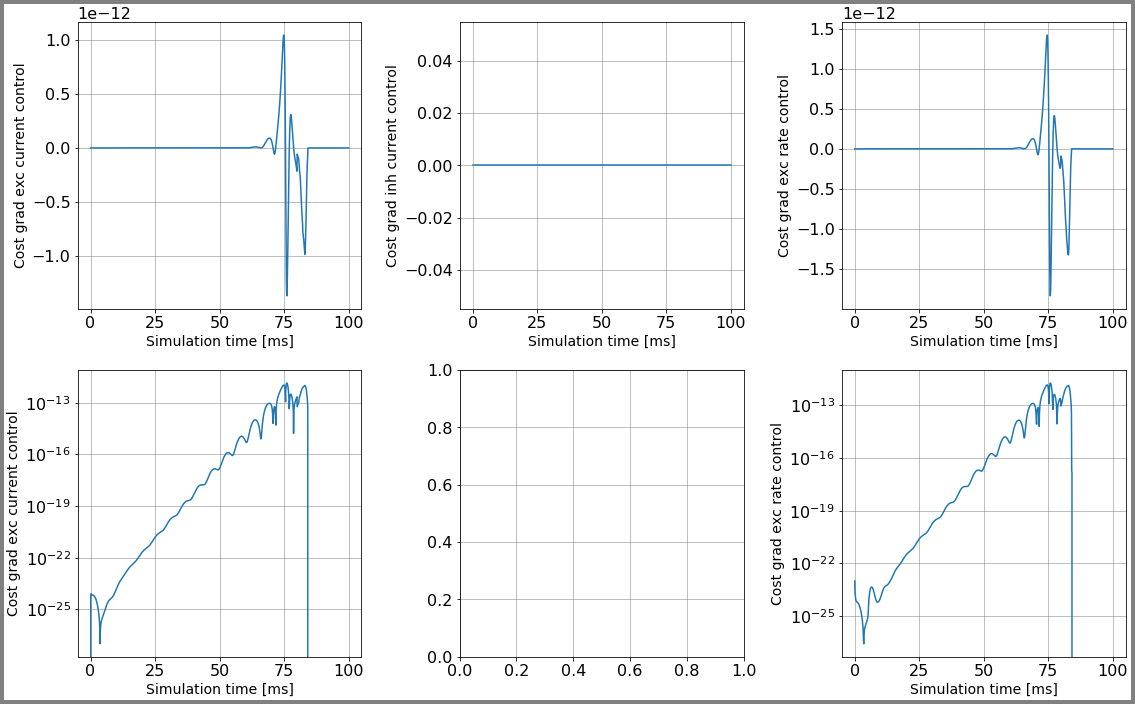

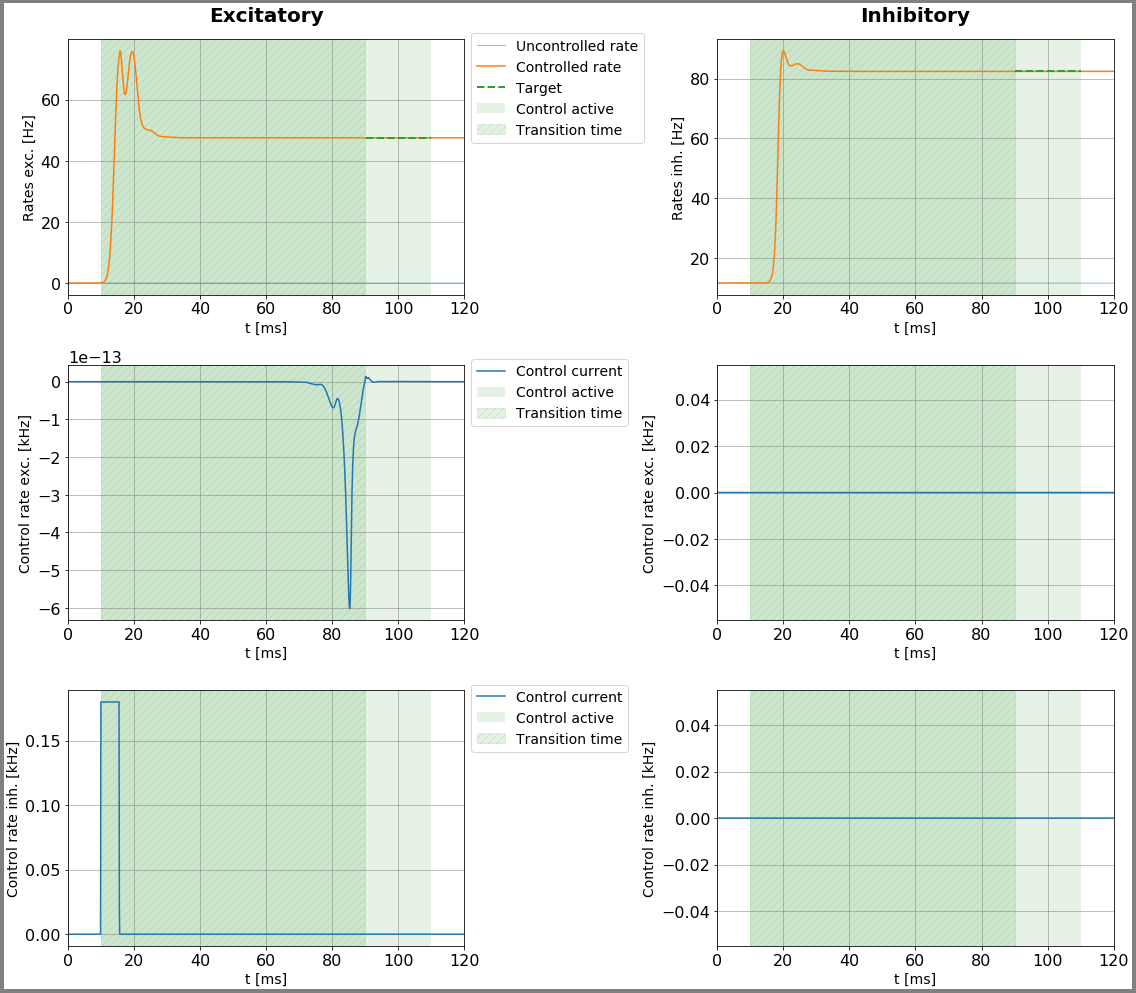

In [15]:
# A.8.a)
case_ind = 18
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.18382882728198002
RUN  1 , total integrated cost =  0.18382873088037774
RUN  2 , total integrated cost =  0.1838254766813584
RUN  3 , total integrated cost =  0.1838216861989157
RUN  4 , total integrated cost =  0.18382161652804127
RUN  5 , total integrated cost =  0.18382153639792218
RUN  6 , total integrated cost =  0.18382147948746372
RUN  7 , total integrated cost =  0.18382141512711983
RUN  8 , total integrated cost =  0.183821357553309
RUN  9 , total integrated cost =  0.18382129537537276
RUN  10 , total integrated cost =  0.183821233691237
RUN  11 , total integrated cost =  0.18382117839672443
RUN  12 , total integrated cost =  0.1838211122800654
RUN  13 , total integrated cost =  0.18382106329038833
RUN  14 , total integrated cost =  0.18382099469932767
RUN  15 , total integrated cost =  0.18382094655449105
RUN  16 , total integrated cost =  0.18382087990460852
RUN  17 , total integrated c

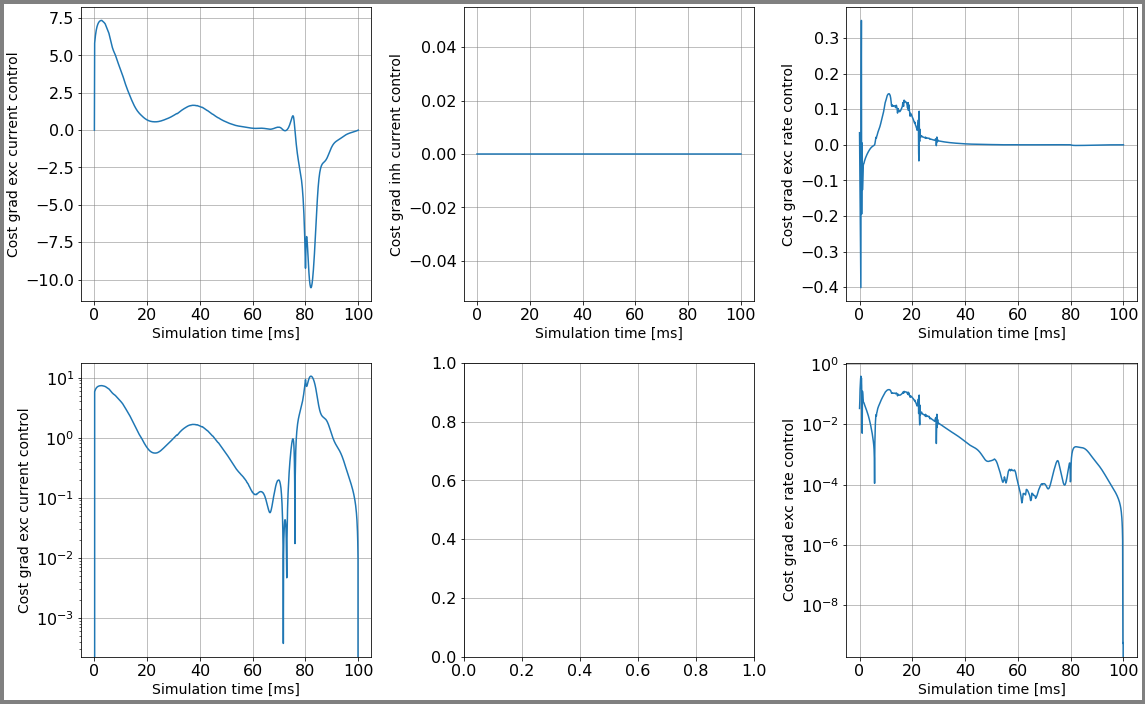

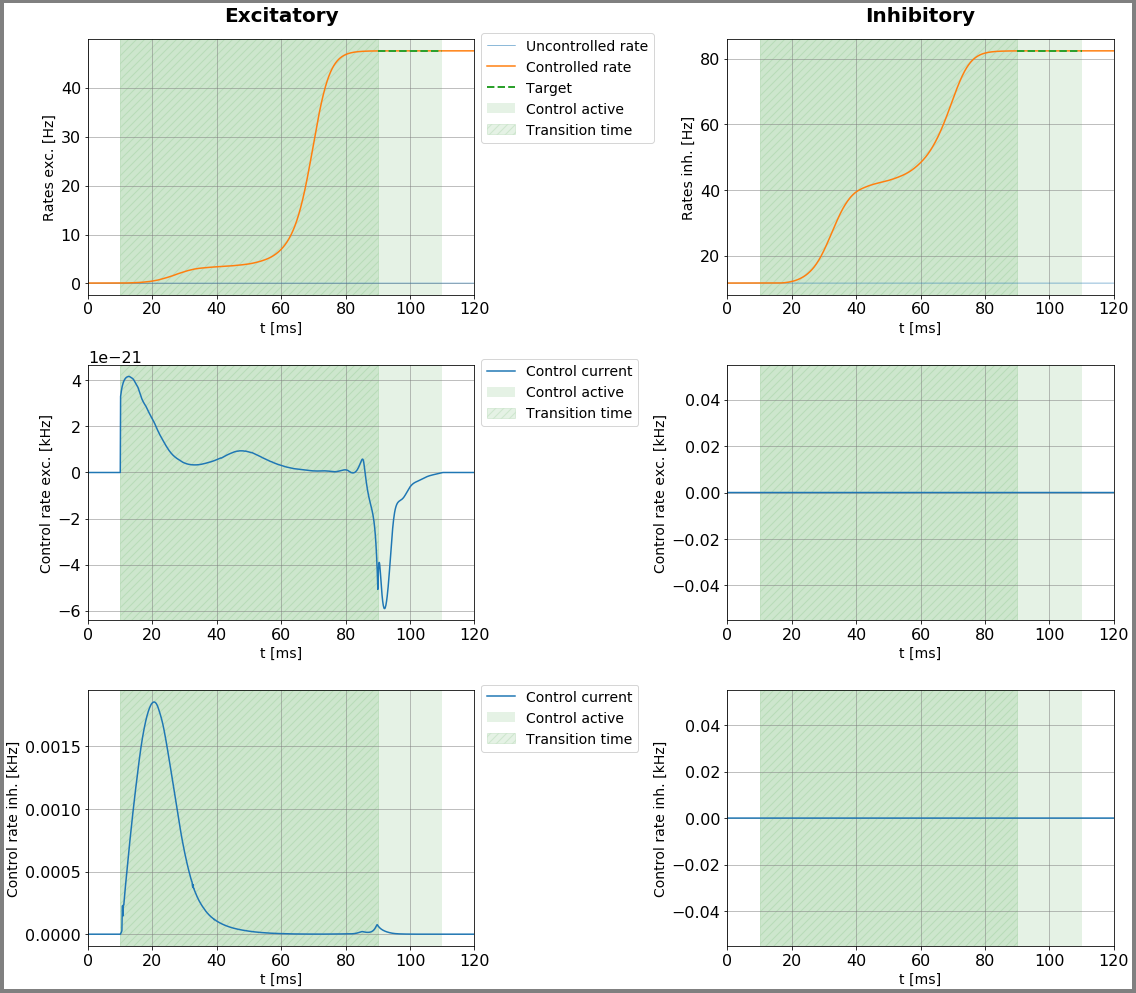

In [27]:
case_ind = 18
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None
max_it = 1000

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 19

set cost params
control input:  [1, 2] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  15.61677338951691
RUN  2 , total integrated cost =  0.0003767804495250874
RUN  3 , total integrated cost =  3.849006968745646e-07
RUN  4 , total integrated cost =  1.6522046718200286e-10
RUN  5 , total integrated cost =  3.8549897146995815e-13
RUN  6 , total integrated cost =  2.5082491277829337e-16
RUN  7 , total integrated cost =  8.855875672689952e-19
RUN  8 , total integrated cost =  6.496914299979199e-22
RUN  9 , total integrated cost =  2.203233855998771e-22
RUN  10 , total integrated cost =  1.2777379001030532e-22
RUN  11 , total integrated cost =  9.326912003884454e-23
RUN  12 , total integrated cost =  7.640518229752116e-23
RUN  13 , total integrated cost =  5.447464970834023e-23
RUN  14 , total integrated cost =  3.2907073914917654e-23
RUN  15 , total integrated cost =  1.337939902126536

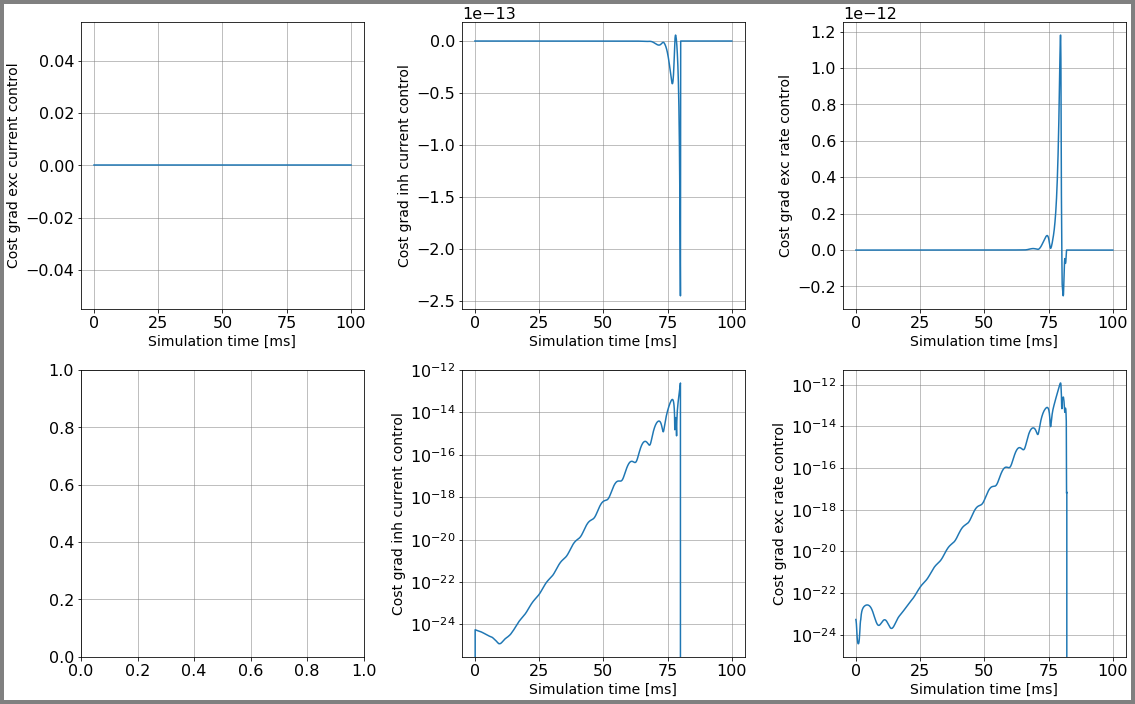

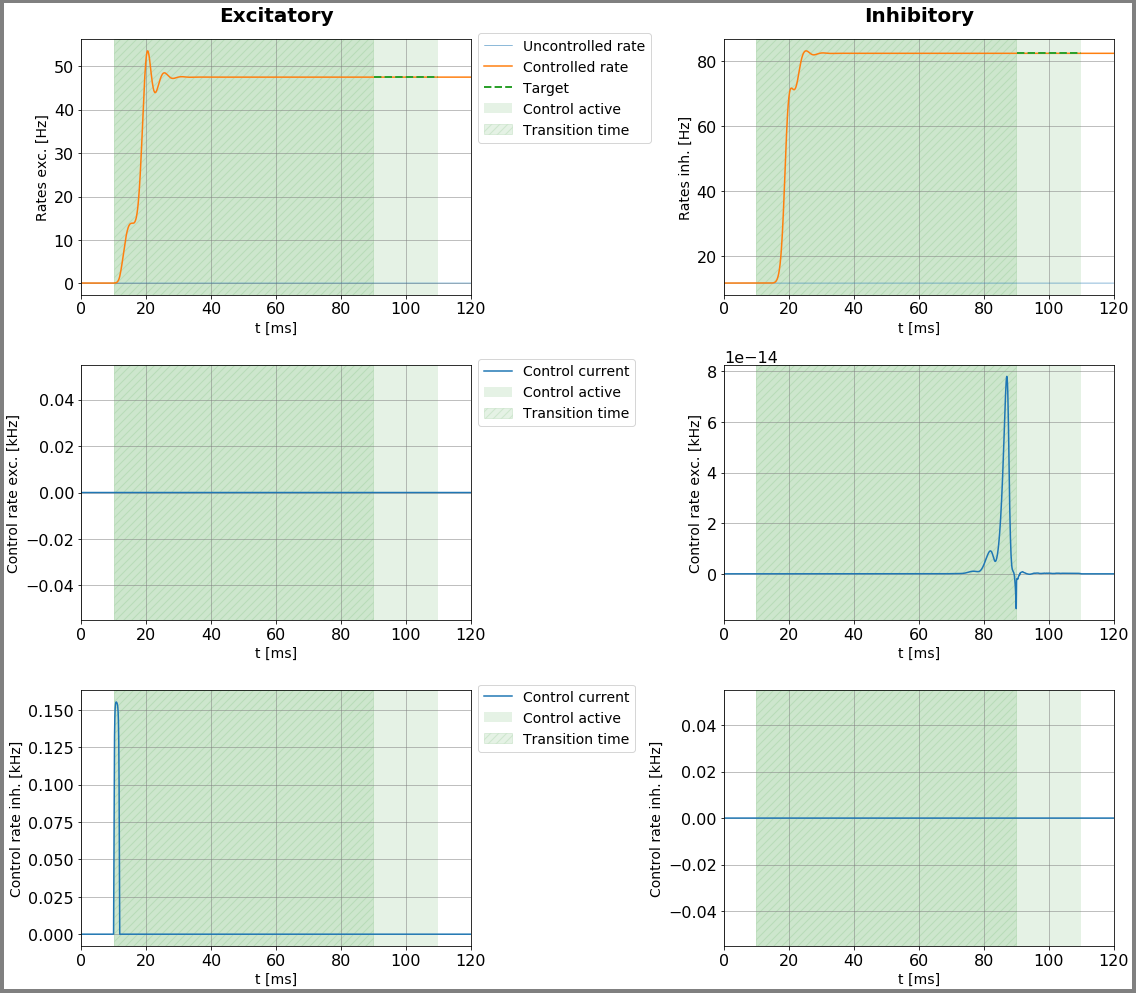

In [17]:
# A.10.a)
case_ind = 19
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  21.406126419675783
RUN  2 , total integrated cost =  19.99674085082043
RUN  3 , total integrated cost =  0.818166775706769
RUN  4 , total integrated cost =  0.21305648888998518
RUN  5 , total integrated cost =  0.21273371008281036
RUN  6 , total integrated cost =  0.21256863595911596
RUN  7 , total integrated cost =  0.21239465872836363
RUN  8 , total integrated cost =  0.21225190937508157
RUN  9 , total integrated cost =  0.21210140877270736
RUN  10 , total integrated cost =  0.2119467075472127
RUN  11 , total integrated cost =  0.21176902252458016
RUN  12 , total integrated cost =  0.21151641739515614
RUN  13 , total integrated cost =  0.21126296617505996
RUN  14 , total integrated cost =  0.2109722505801051
RUN  15 , total integrated cost =  0.21064864241772224
RUN  16 , total integrated cost =  0.21046886979182278
RUN  17 , total integrated cos

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.18328551041613464
RUN  5000 , total integrated cost =  0.18328551041613464
Improved over  5000  iterations by  99.99974747692691  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7145072726007248
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.104443533096923


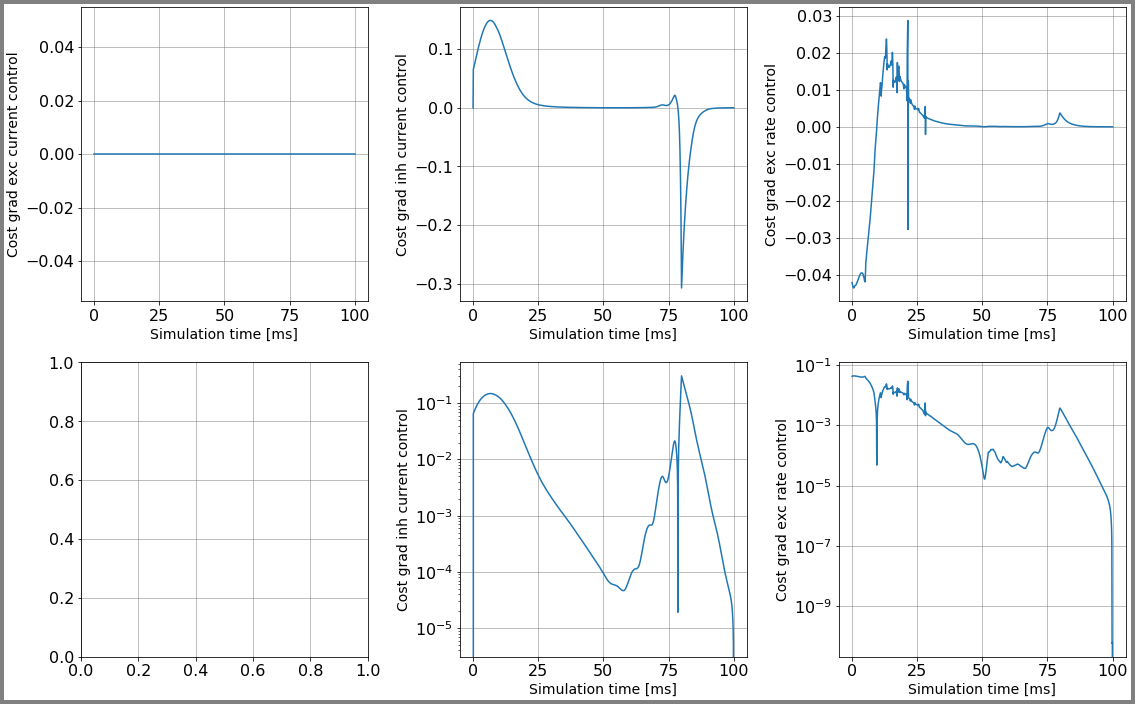

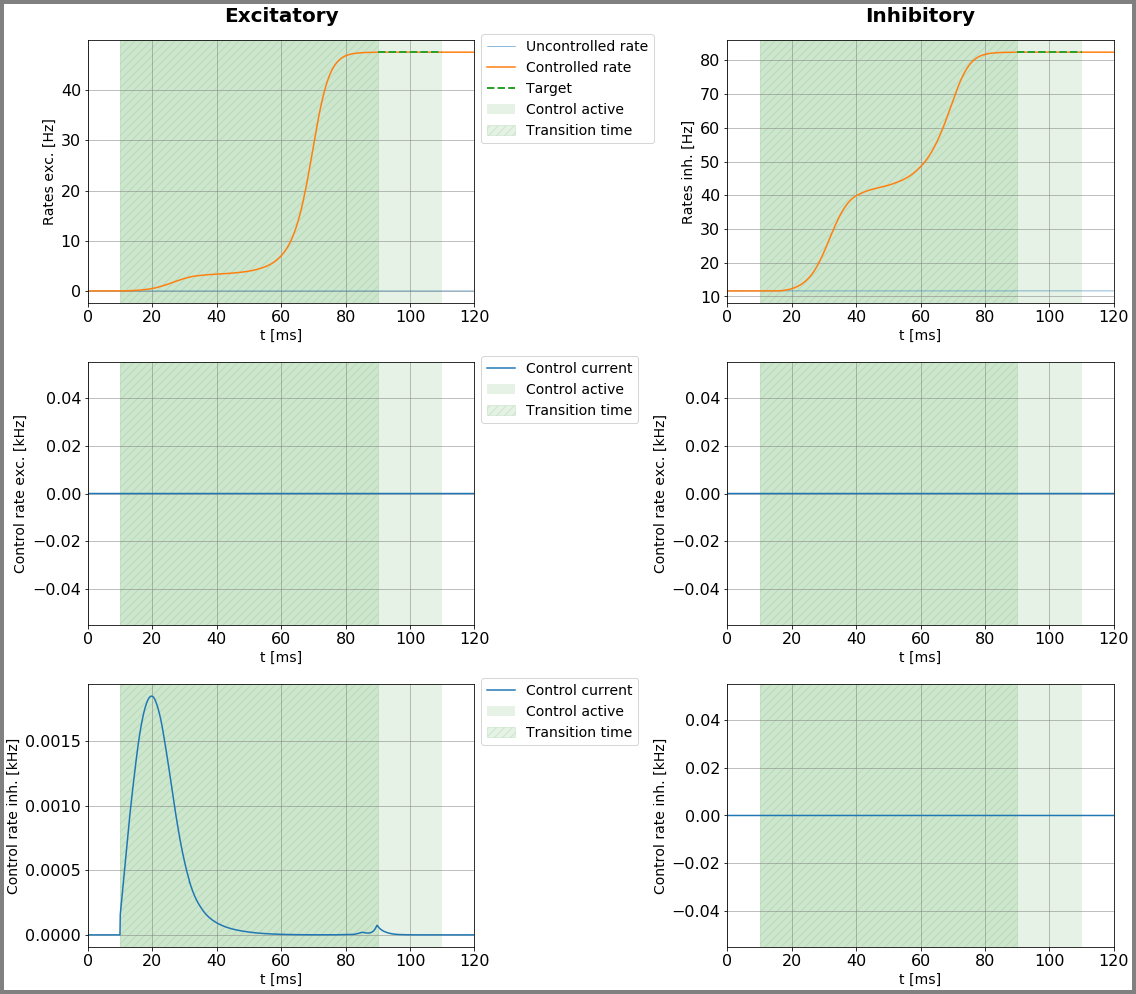

In [18]:
case_ind = 19
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 20

set cost params
control input:  [0, 1, 2] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  15.61677338951691
RUN  2 , total integrated cost =  0.00037351254031044634
RUN  3 , total integrated cost =  0.00014550227783660384
RUN  4 , total integrated cost =  4.423873232798419e-05
RUN  5 , total integrated cost =  1.7158371350324423e-05
RUN  6 , total integrated cost =  1.156381854074289e-05
RUN  7 , total integrated cost =  7.325244863215952e-06
RUN  8 , total integrated cost =  5.005312770481322e-06
RUN  9 , total integrated cost =  3.857942723519586e-06
RUN  10 , total integrated cost =  3.044448451548825e-06
RUN  11 , total integrated cost =  2.416172399776897e-06
RUN  12 , total integrated cost =  2.038667760786301e-06
RUN  13 , total integrated cost =  1.7226126086392653e-06
RUN  14 , total integrated cost =  1.439454906417567e-06
RUN  15 , total integrated cost =  1.2473823568683

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  3484 , total integrated cost =  4.391191073469145e-25
Improved over  3484  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7016146935676397
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.56012444472674
Problem in initial value trasfer:  Vmean_exc -56.174591292541265 -56.174593601098415


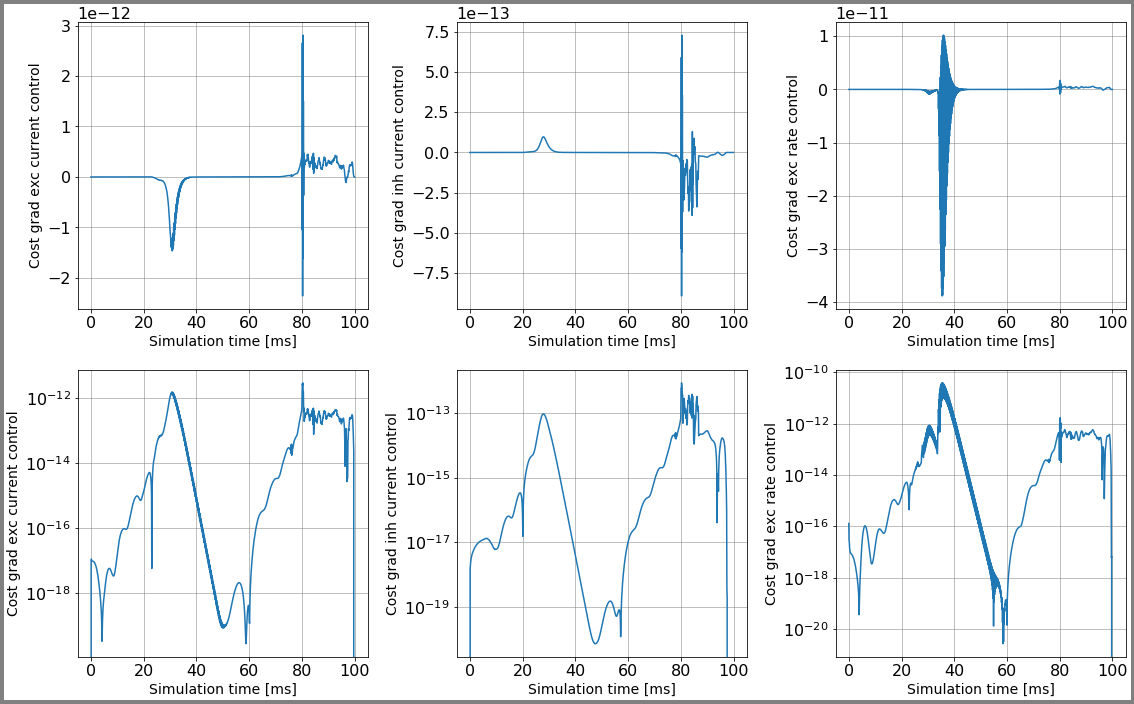

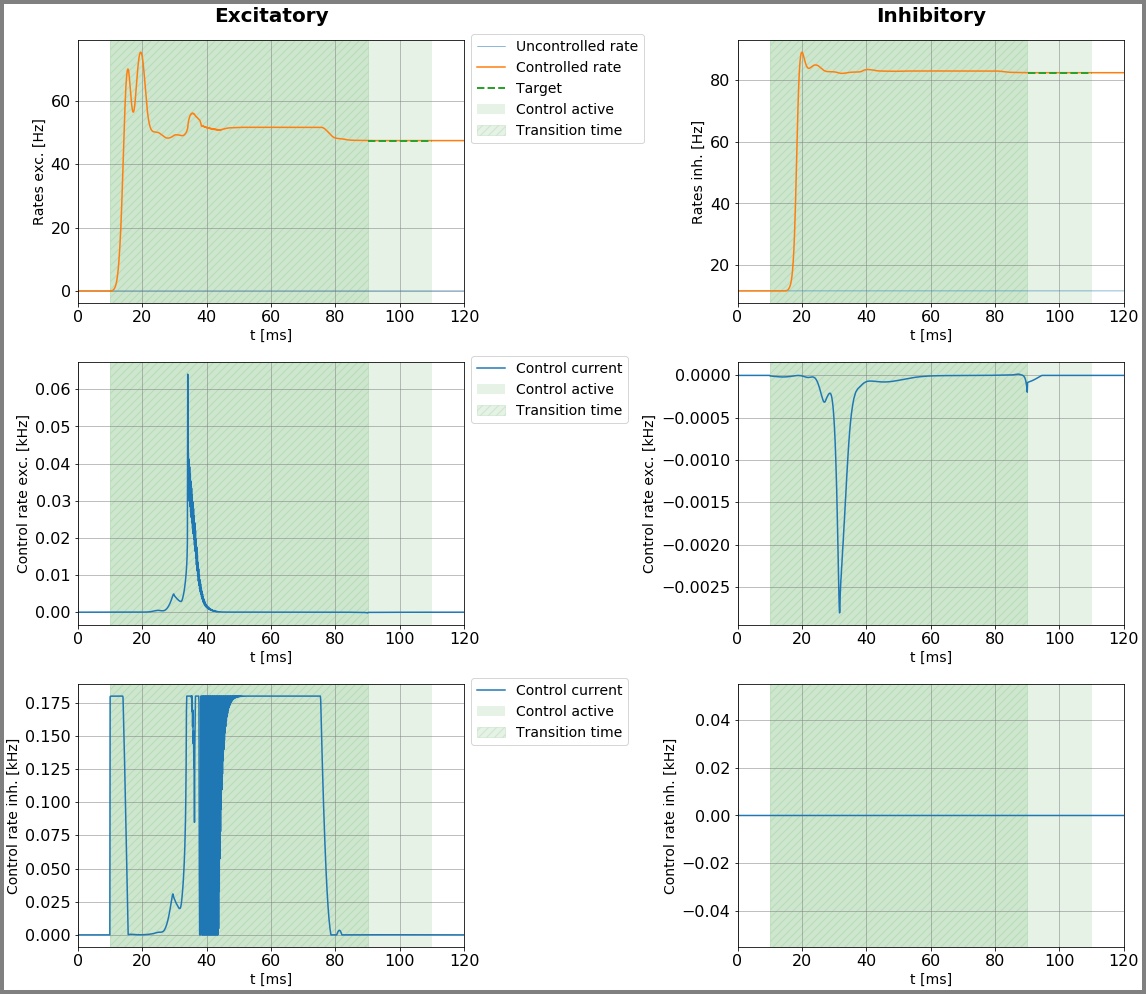

In [19]:
# A.12.a)
case_ind = 20
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72581.68854821922
RUN  1 , total integrated cost =  21.406126419675783
RUN  2 , total integrated cost =  10.846420318731765
RUN  3 , total integrated cost =  8.986130474216807
RUN  4 , total integrated cost =  7.465045275488109
RUN  5 , total integrated cost =  7.149202806712925
RUN  6 , total integrated cost =  5.0287754159410465
RUN  7 , total integrated cost =  3.5466313689899236
RUN  8 , total integrated cost =  2.1263078983435624
RUN  9 , total integrated cost =  1.4380848225895593
RUN  10 , total integrated cost =  1.2924518292990876
RUN  11 , total integrated cost =  1.1514696017837536
RUN  12 , total integrated cost =  1.0937506413003197
RUN  13 , total integrated cost =  1.0750721679231605
RUN  14 , total integrated cost =  1.0746079347430666
RUN  15 , total integrated cost =  1.0741954029488503
RUN  16 , total integrated cost =  1.0737963090722653
RUN  17 , total integrated cost =  1.07343

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  4837 , total integrated cost =  0.18326974514888314
Improved over  4837  iterations by  99.99974749864764  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7143996540908416
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.108141745830093


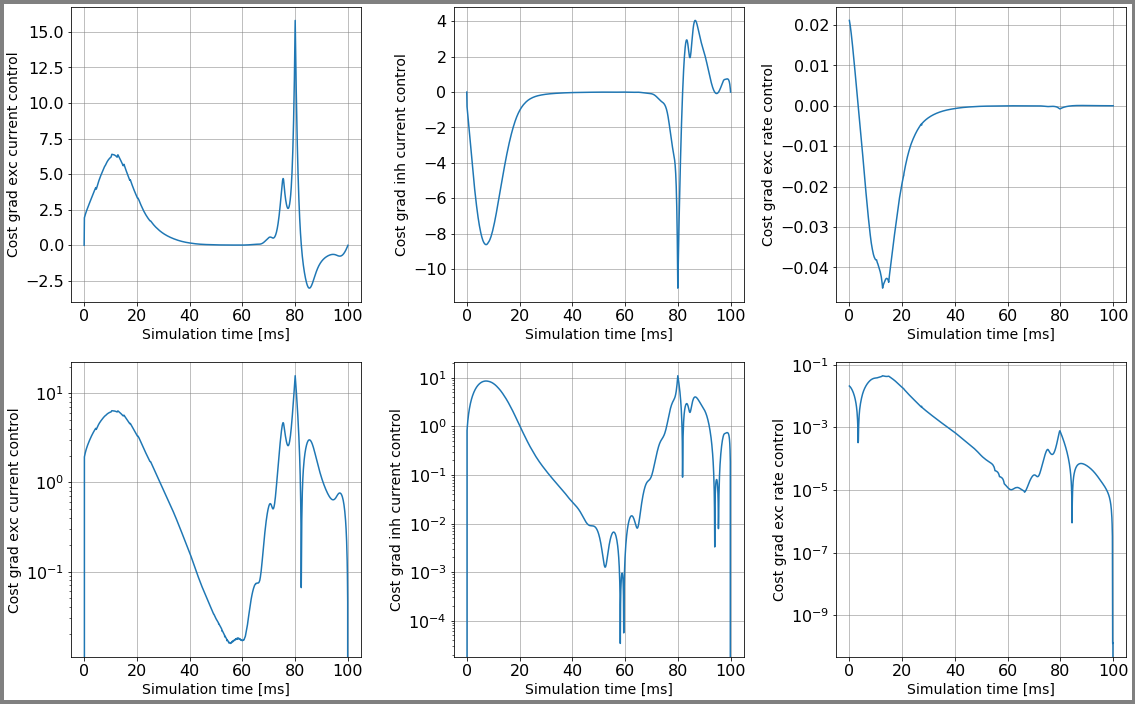

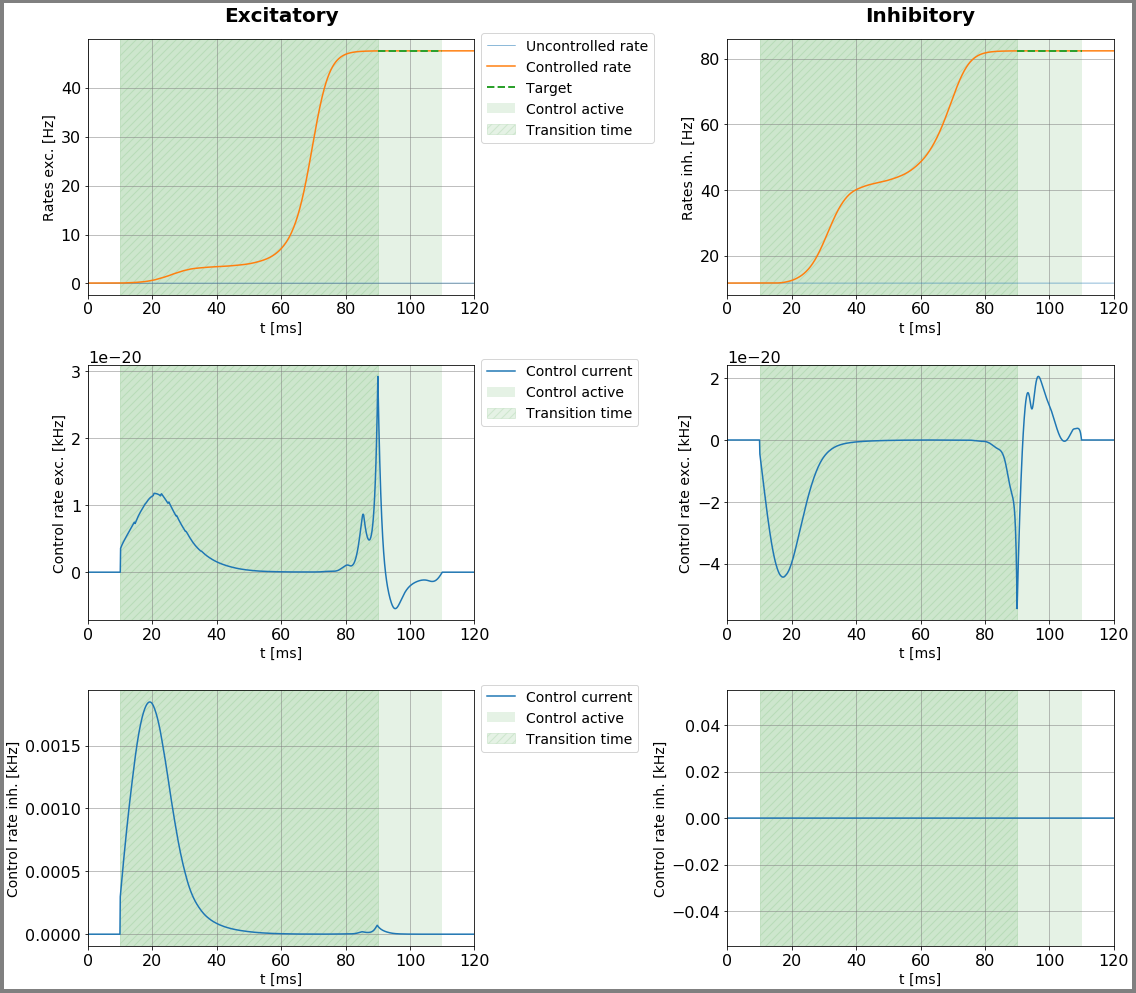

In [20]:
case_ind = 20
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )